# Ground-Truth Calibration of NASA POWER Satellite Weather Data
### Spatio-Temporal ML Pipeline for Hourly Temperature Prediction

This notebook reproduces the full pipeline described in Chapter 3 (Research
Methodology): retrieving and cleaning IoT ground-truth weather station data
and NASA POWER hourly reanalysis data for four sites, engineering features,
running descriptive/diagnostic/correlation analysis, training predictive
models (Linear Regression, Random Forest, XGBoost, and a stacking ensemble)
to calibrate NASA's satellite-derived temperature against ground-truth
measurements, and explaining the best model's predictions with SHAP.

**Study sites** (Akwa Ibom region, Nigeria): `astal_uyo`, `daringpotato`,
`dauntedlemon`, `dazetrumpet`

**Pipeline stages**
1. Data retrieval & resampling to hourly resolution
2. Cleaning & linear interpolation of missing values
3. Descriptive / diagnostic / correlation analysis
4. Predictive modelling & performance evaluation (MAE, MSE, RMSE, R²)
5. Model explainability with SHAP


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data_pipeline import build_full_dataset
from eda import plot_time_series, plot_correlation_heatmap
from modeling import (
    load_dataset, chronological_split, FEATURE_COLS, TARGET_COL,
    train_and_evaluate,
)
from shap_explain import explain as shap_explain

pd.set_option('display.max_columns', None)


## 1. Data Retrieval & Preprocessing

In [2]:
df = build_full_dataset()
print(f"{len(df):,} hourly records across {df['station'].nunique()} stations")
df.head()

17,906 hourly records across 4 stations


,nasa_solar_irradiance,nasa_temperature_c,nasa_relative_humidity,nasa_wind_speed_ms,nasa_wind_direction_deg,gt_pressure_hpa,gt_temperature_c,gt_humidity_percent,gt_wind_dir_deg,gt_wind_spd_ms,gt_rain_1hr_mm,gt_light_intensity_lux,gt_uv_index,station,lat,lon,gt_interpolated
timestamp,,,,,,,,,,,,,,,,,
2023-06-07 10:00:00,1.55,26.99,87.12,1.95,226.63,NaN,28.8950,81.5200,NaN,NaN,NaN,NaN,NaN,dauntedlemon,5.02,7.93,False
2023-06-07 11:00:00,1.80,27.15,85.31,2.06,224.69,NaN,28.9675,80.9900,NaN,NaN,NaN,NaN,NaN,dauntedlemon,5.02,7.93,False
2023-06-07 12:00:00,2.22,27.33,84.19,2.11,221.55,NaN,29.0375,80.6950,NaN,NaN,NaN,NaN,NaN,dauntedlemon,5.02,7.93,False
2023-06-07 13:00:00,1.91,27.41,83.75,2.17,218.72,NaN,28.9950,81.2950,NaN,NaN,NaN,NaN,NaN,dauntedlemon,5.02,7.93,False
2023-06-07 14:00:00,1.95,27.36,84.06,2.22,217.27,NaN,28.9100,81.4475,NaN,NaN,NaN,NaN,NaN,dauntedlemon,5.02,7.93,False


In [3]:
df['station'].value_counts()

station
dazetrumpet     5758
dauntedlemon    4359
astal_uyo       4331
daringpotato    3458
Name: count, dtype: int64

Each ground-truth station streams sensor readings roughly every 15 minutes
via a blockchain-logged IoT pipeline. These are resampled to an hourly mean
and inner-joined with NASA POWER's hourly `T2M` / `RH2M` / `ALLSKY_SFC_SW_DWN`
/ `WS2M` / `WD2M` fields for the matching coordinate and hour. Missing values
are filled with linear interpolation, per station, in time order.

## 2. Descriptive & Diagnostic Analysis

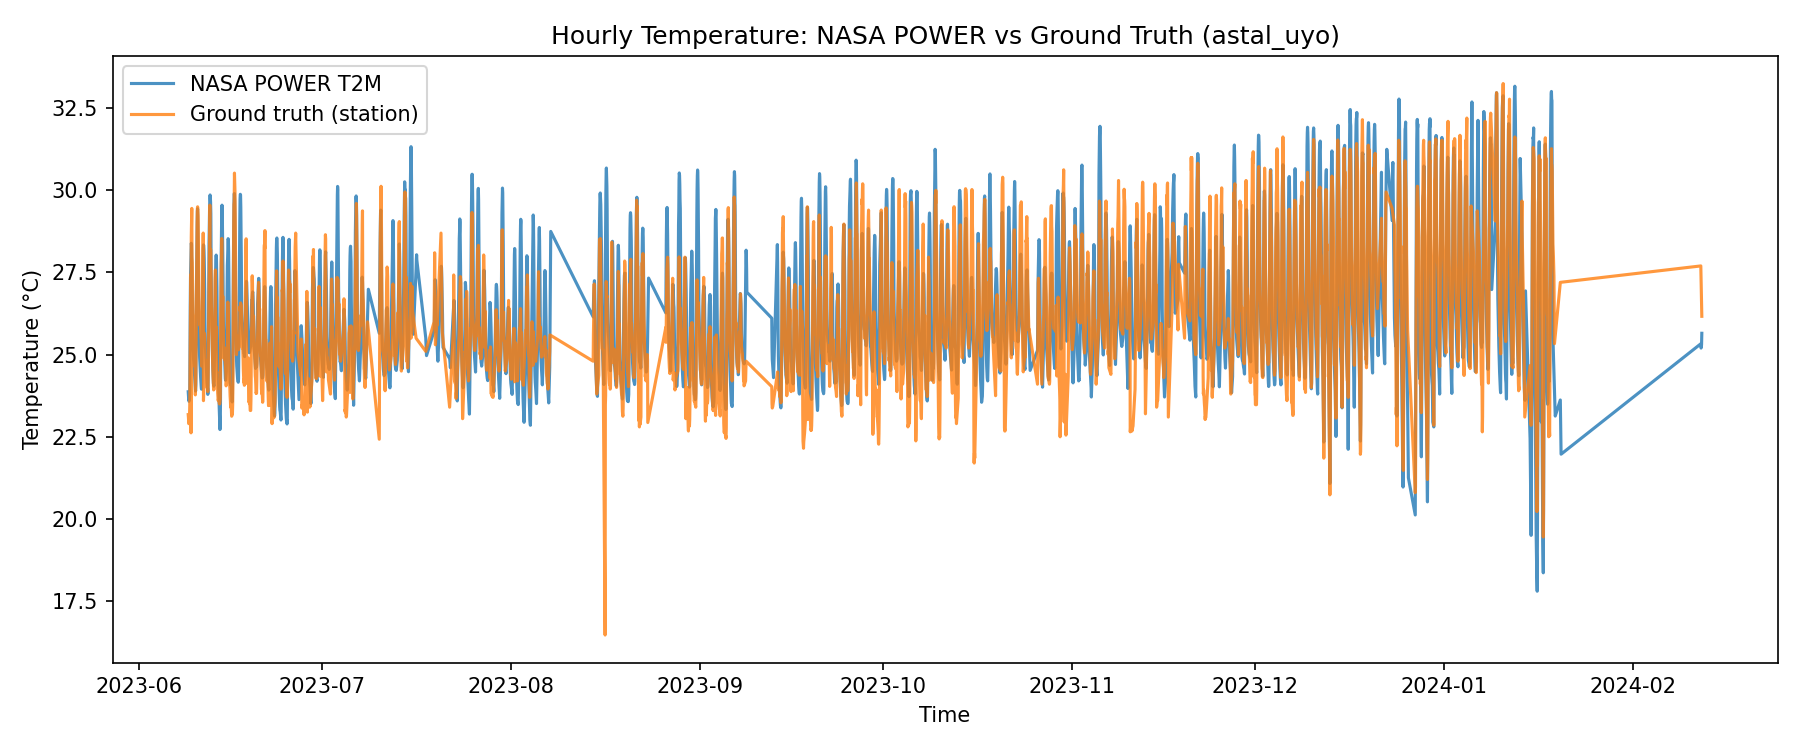

In [4]:
display(Image(plot_time_series(df, 'astal_uyo')))

NASA POWER's satellite-derived temperature tracks the ground-truth station closely in shape but with a systematic offset — motivating a calibration model.

## 3. Correlation Analysis

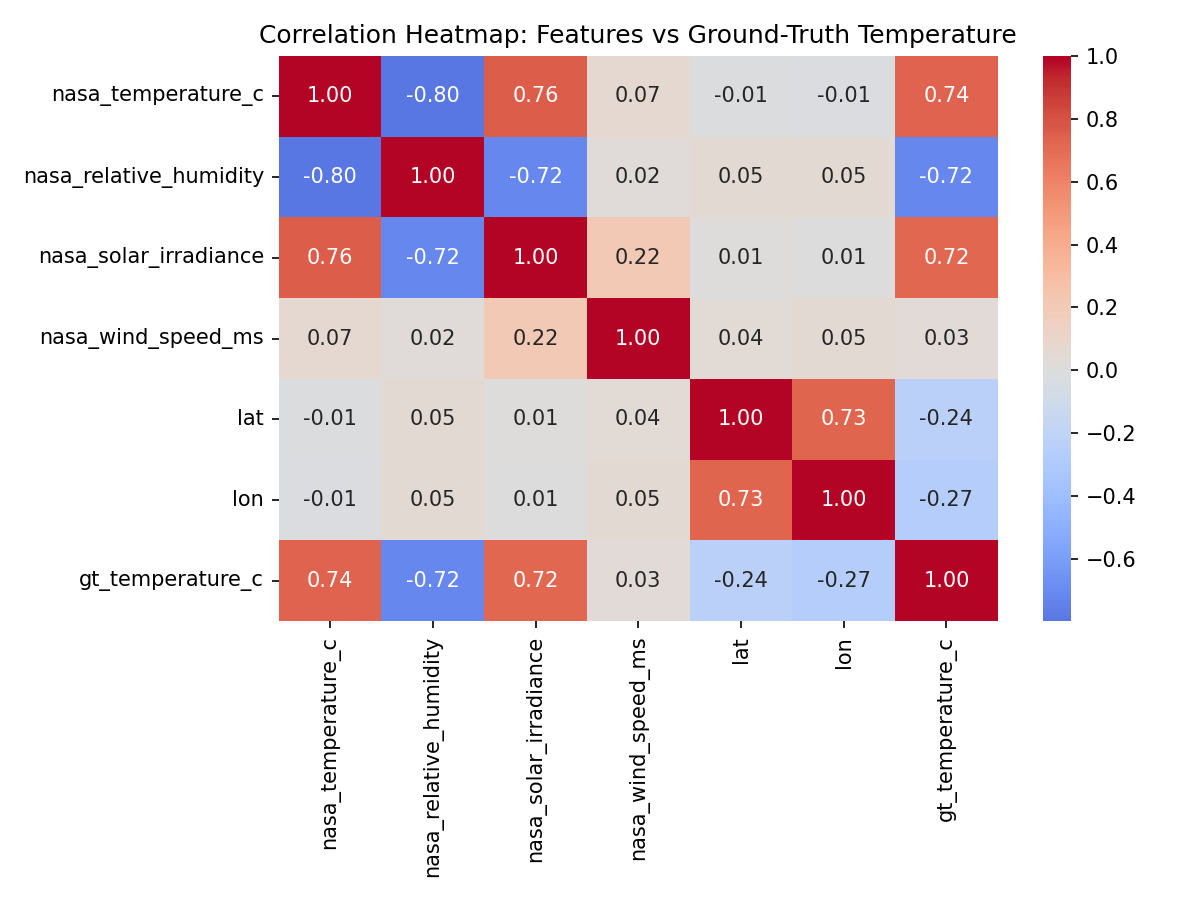

gt_temperature_c          1.000000
nasa_temperature_c        0.738326
nasa_solar_irradiance     0.719622
nasa_wind_speed_ms        0.032372
lat                      -0.241347
lon                      -0.270858
nasa_relative_humidity   -0.716574
Name: gt_temperature_c, dtype: float64

In [5]:
path, corr = plot_correlation_heatmap(df, FEATURE_COLS, TARGET_COL)
display(Image(path))
corr[TARGET_COL].sort_values(ascending=False)

NASA's own temperature reading is (unsurprisingly) the strongest predictor of ground truth, followed by solar irradiance; relative humidity is strongly negatively correlated, as expected physically.

## 4. Predictive Modelling

We use an 80/20 **chronological** train/test split (no shuffling, matching
the methodology), standardize features, and compare four models:

- Linear Regression (baseline)
- Random Forest
- XGBoost (hyperparameters tuned via `GridSearchCV` with time-series CV)
- Stacking ensemble (XGBoost + Random Forest + Linear Regression, with a
  Linear Regression meta-learner)

Each model is evaluated with **MAE**, **MSE**, **RMSE**, and **R²**.


In [6]:
results = train_and_evaluate()
import json
print(json.dumps(results, indent=2))

{
  "LinearRegression": {
    "MAE": 2.2086,
    "MSE": 7.7979,
    "RMSE": 2.7925,
    "R2": 0.6357
  },
  "RandomForest": {
    "MAE": 1.898,
    "MSE": 6.2169,
    "RMSE": 2.4934,
    "R2": 0.7096
  },
  "XGBoost": {
    "MAE": 1.9113,
    "MSE": 6.003,
    "RMSE": 2.4501,
    "R2": 0.7196
  },
  "XGBoost_best_params": {
    "learning_rate": 0.05,
    "max_depth": 5,
    "n_estimators": 150,
    "reg_alpha": 4,
    "reg_lambda": 1,
    "subsample": 0.8
  },
  "StackingEnsemble": {
    "MAE": 1.8425,
    "MSE": 5.6714,
    "RMSE": 2.3815,
    "R2": 0.735
  },
  "n_train": 14324,
  "n_test": 3582,
  "best_model": "StackingEnsemble"
}


## 5. Results

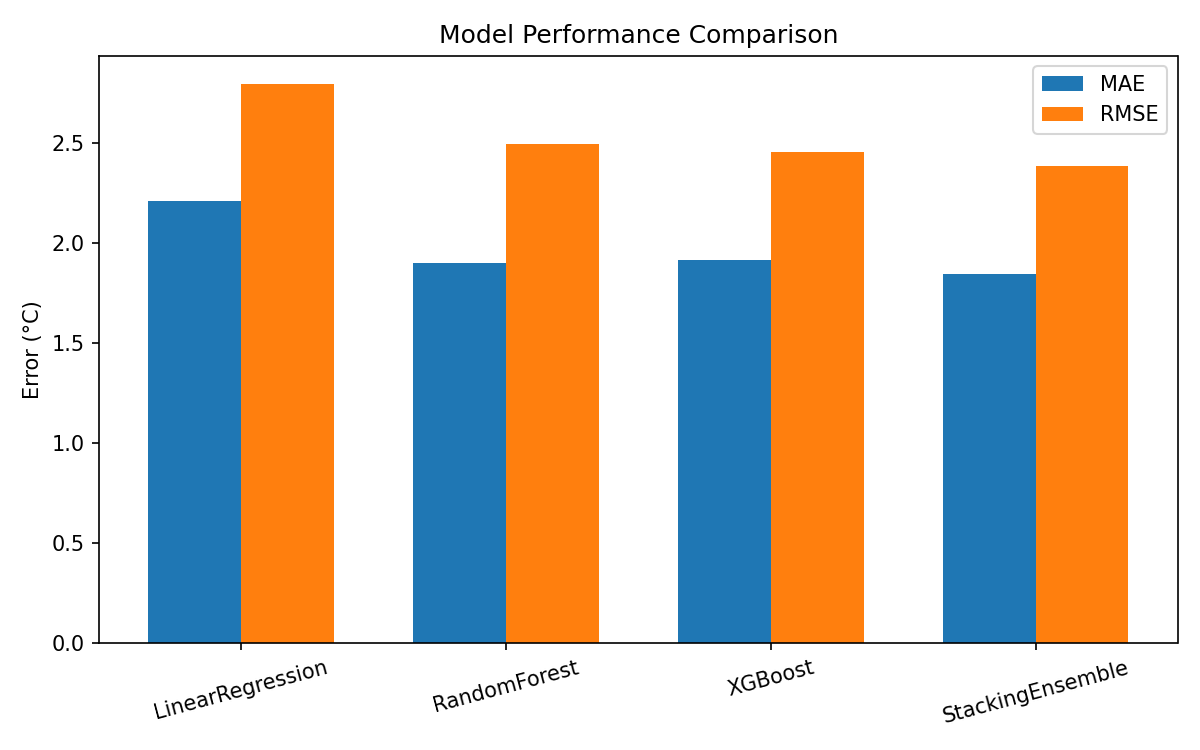

In [7]:
display(Image('../reports/figures/model_comparison.png'))

**Summary:** The stacking ensemble achieves the lowest error and highest
R², confirming the thesis's hypothesis that combining tree-based and linear
learners improves calibration accuracy over any single model. The trained
pipeline (model + scaler) is persisted to `models/best_model.pkl` for reuse —
see `src/predict.py` for a minimal inference example.


## 6. Model Explainability (SHAP)

To understand *why* the best model (the stacking ensemble) makes the
predictions it does, we compute SHAP (SHapley Additive exPlanations) values
on a sample of the test set. SHAP attributes each prediction to the
contribution of each input feature, in the feature's original units, using
game-theoretic Shapley values — giving both global feature importance and
per-prediction explanations.


In [8]:
shap_values, mean_abs_shap = shap_explain()
mean_abs_shap

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X h

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has fe

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has fe

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has fe

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
ExactExplainer explainer: 301it [00:34,  7.48it/s]                         

Explained model: StackingEnsemble
Mean |SHAP value| per feature:
nasa_solar_irradiance     2.100961
nasa_temperature_c        1.152598
lat                       0.609059
nasa_relative_humidity    0.513338
lon                       0.255472
nasa_wind_speed_ms        0.206181
dtype: float64

Saved: /home/claude/project/notebooks/../src/../reports/figures/shap_summary_beeswarm.png
Saved: /home/claude/project/notebooks/../src/../reports/figures/shap_summary_bar.png
Saved: /home/claude/project/notebooks/../src/../reports/figures/shap_waterfall_example.png


nasa_solar_irradiance     2.100961
nasa_temperature_c        1.152598
lat                       0.609059
nasa_relative_humidity    0.513338
lon                       0.255472
nasa_wind_speed_ms        0.206181
dtype: float64

**Global feature importance (mean |SHAP value|):**

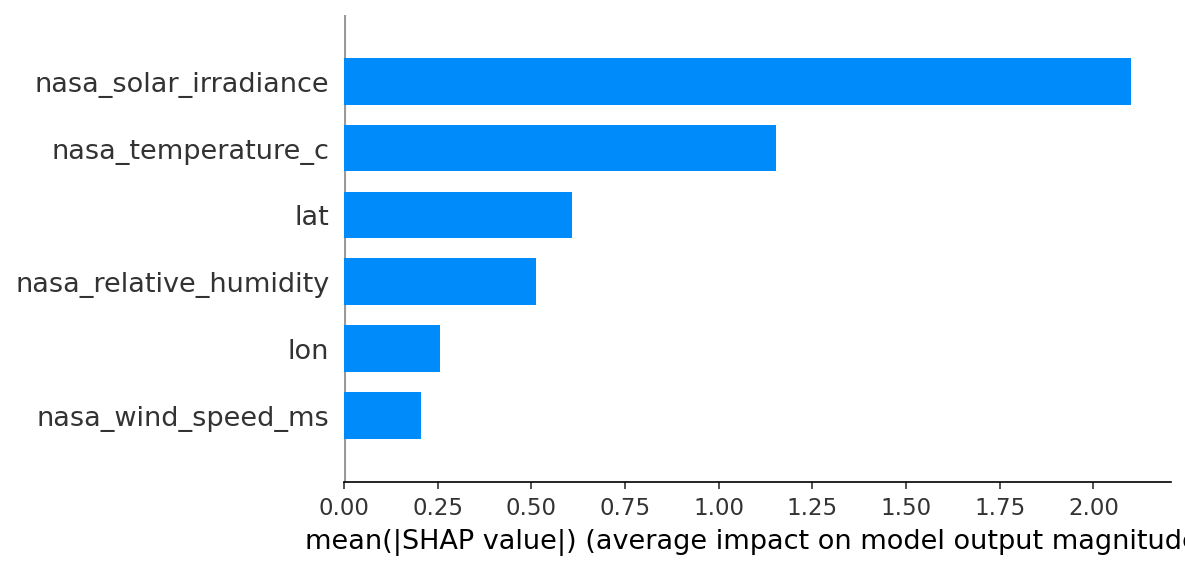

In [9]:
display(Image('../reports/figures/shap_summary_bar.png'))

**Direction of each feature's effect** (beeswarm — red = high feature value, blue = low):

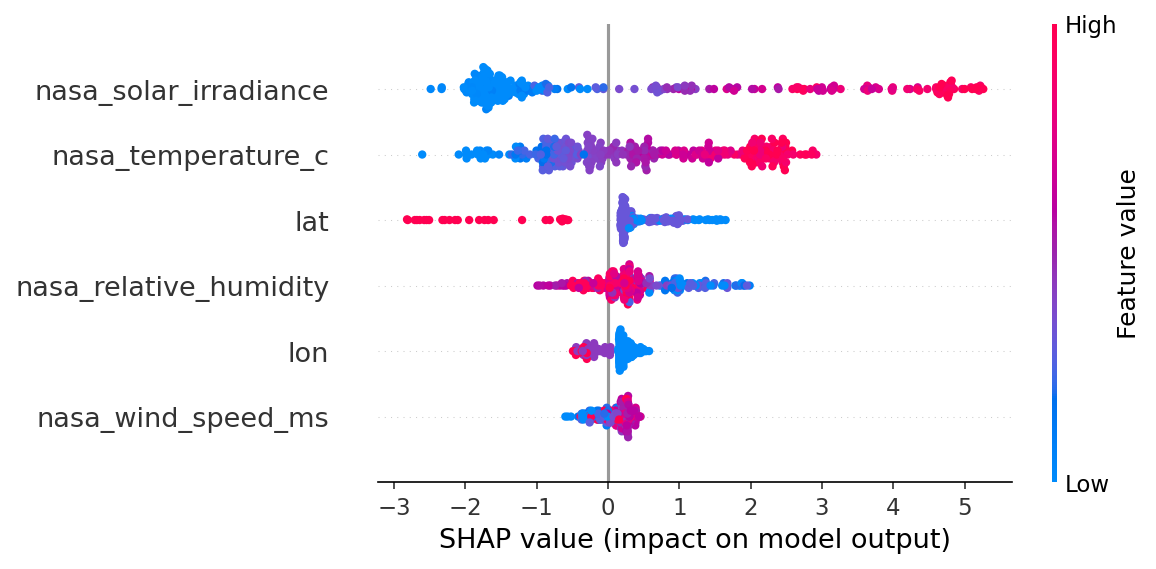

In [10]:
display(Image('../reports/figures/shap_summary_beeswarm.png'))

**Breakdown of a single prediction:**

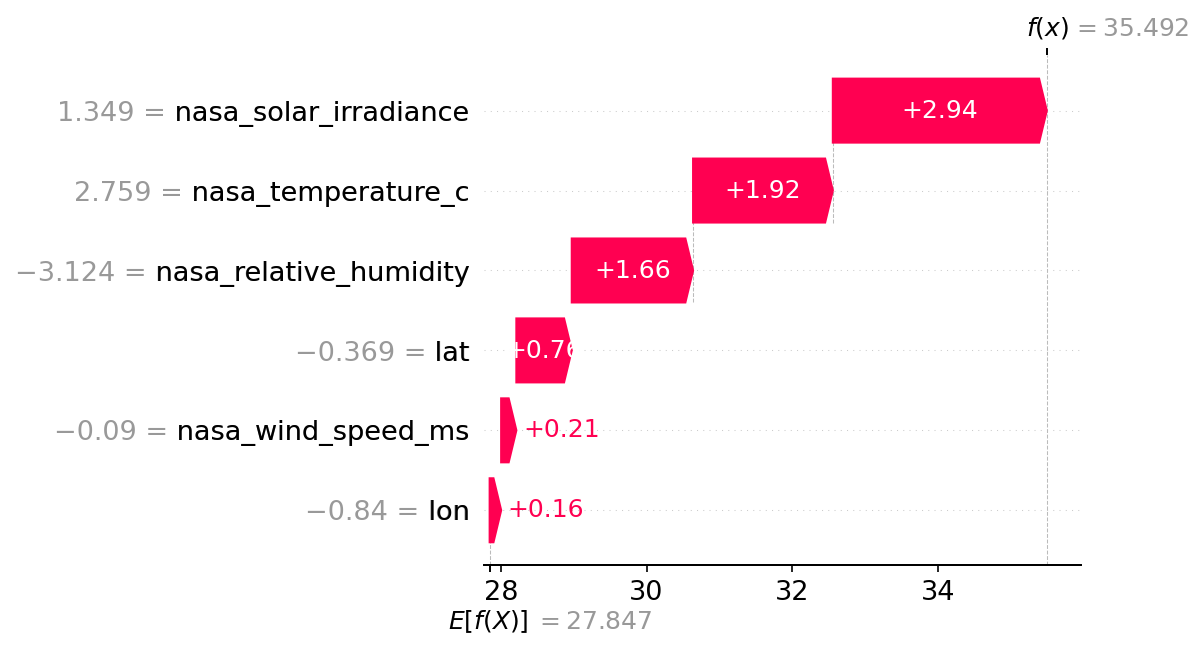

In [11]:
display(Image('../reports/figures/shap_waterfall_example.png'))

**Interpretation:** NASA's own solar irradiance and temperature readings
dominate the calibrated prediction — both push the prediction up when high
and down when low, matching physical intuition. Latitude/longitude capture
residual site-specific offsets between stations, and relative humidity has
a consistent negative effect on predicted temperature, consistent with the
correlation analysis in Section 3.
